# rosbag2-reader usage example

In [17]:
from ros2bag_reader import ROS2BagReader
import matplotlib.pyplot as plt

In [18]:
reader = ROS2BagReader("recording")
reader.summary()

Bag Summary
-----------
Storage: sqlite3
Duration: 52.12 seconds
Message Count: 6645
Files: 1

Topics:
    /parameter_events
        Type: rcl_interfaces/msg/ParameterEvent
        Messages: 0

    /rosout
        Type: rcl_interfaces/msg/Log
        Messages: 10

    /turtle1/cmd_vel
        Type: geometry_msgs/msg/Twist
        Messages: 119

    /turtle1/color_sensor
        Type: turtlesim/msg/Color
        Messages: 3258

    /turtle1/pose
        Type: turtlesim/msg/Pose
        Messages: 3258



In [19]:
pose = reader.get_messages("/turtle1/pose")

print("Message item length:", len(pose[0]))
print("Message timestamp:", pose[0][0])
print("Message data:", pose[0][1])

Message item length: 2
Message timestamp: 1771256139516957816
Message data: turtlesim.msg.Pose(x=5.544444561004639, y=5.544444561004639, theta=0.0, linear_velocity=0.0, angular_velocity=0.0)


In [20]:
pose_data = reader.get_field_array("/turtle1/pose", ["x", "y", "theta"])
timestamps = reader.get_time_array("/turtle1/pose", reference='topic')
reader.close()

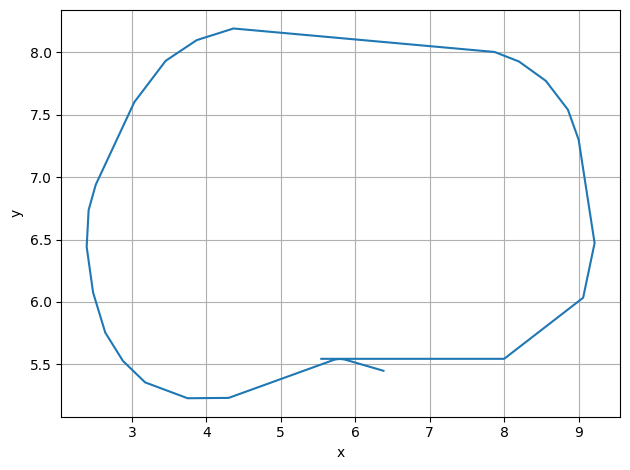

In [21]:
plt.plot(pose_data[:,0], pose_data[:,1])
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.tight_layout()

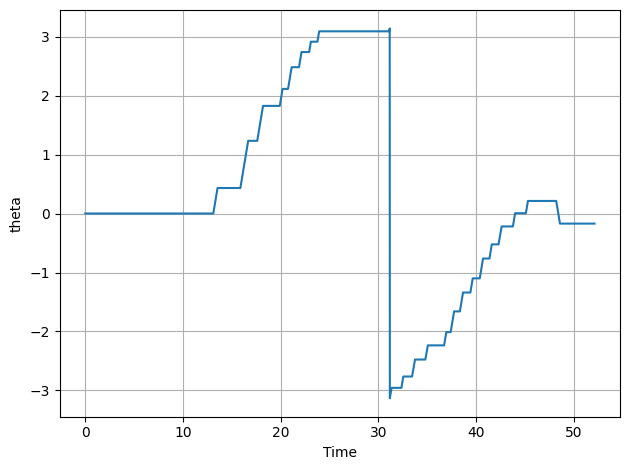

In [22]:
plt.plot(timestamps, pose_data[:,2])
plt.xlabel("Time")
plt.ylabel("theta")
plt.grid()
plt.tight_layout()